## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.1.3 - Solving MISP with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Maximum independent set (S): [1, 4, 6, 11]


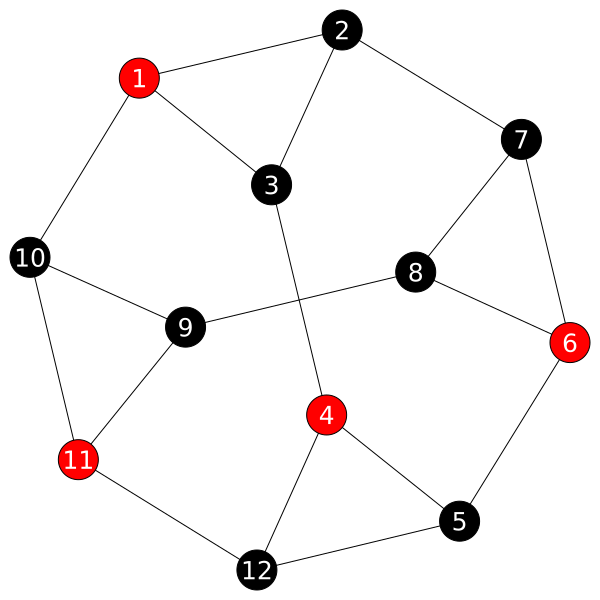

In [1]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/misp_utils.jl")

# Create graph
graph = Graphs.smallgraph("truncatedtetrahedron")

# Auxiliary variables to simplify notation
V = 1:Graphs.nv(graph)  # Range of vertices 
E = Graphs.edges(graph) # Graph edges

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, x[v in V], Bin)

# Objective function: maximize the total of selected vertices
@objective(model, Max, sum(x[v] for v in V))

# Independence constraint
@constraint(model, [e in E], x[e.src] + x[e.dst] <= 1)

# Run the solver
JuMP.optimize!(model)

# Independent set S
S = [v for v in V if JuMP.value(x[v]) > 0.5]

# Print solution
println("Maximum independent set (S): $S")

# Plot solution
plot_solution(graph, S)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.2.4 - Solving VCP with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Vertex Cover set (C): [2, 4, 5, 7]


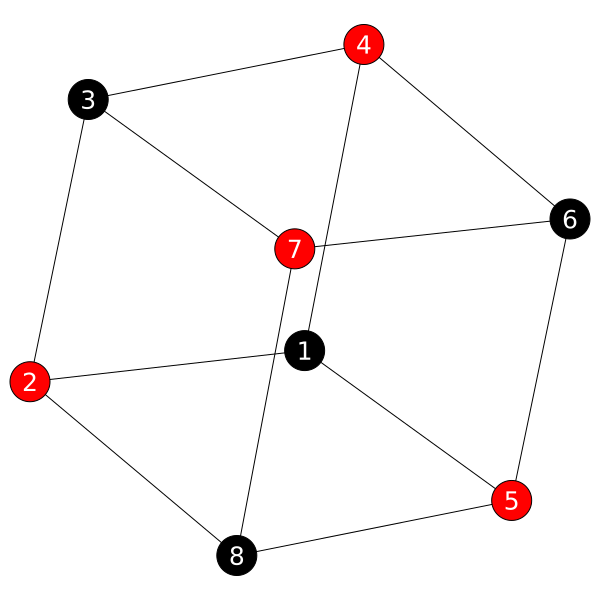

In [2]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/vcp_utils.jl")

# Create graph
graph = Graphs.smallgraph("cubical")

# Auxiliary variables to simplify notation
V = 1:Graphs.nv(graph)  # Range of vertices
E = Graphs.edges(graph) # Graph edges

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, x[v in V], Bin)

# Objective function: minimize the total of selected vertices
@objective(model, Min, sum(x[v] for v in V))

# Vertex Cover constraint
@constraint(model, [e in E], x[e.src] + x[e.dst] >= 1)

# Run the solver
JuMP.optimize!(model)

# Vertex Cover C
C = [v for v in V if JuMP.value(x[v]) > 0.5]

# Print solution
println("Vertex Cover set (C): $C")

# Plot solution
plot_solution(graph, C)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.3.3 - Solving GCP with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Chromatic number: 3.0
Partition: [[2, 5, 6], [4, 7, 8], [1, 3, 9, 10]]


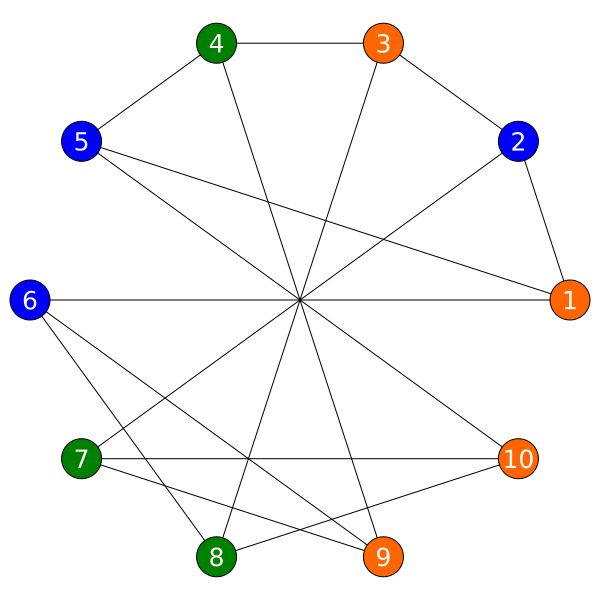

In [4]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/gcp_utils.jl")

# Create graph
graph = Graphs.smallgraph("petersen")

# Auxiliary variables to simplify notation
V = 1:Graphs.nv(graph)  # Range of vertices
C = 1:Graphs.nv(graph)  # Range of colors
E = Graphs.edges(graph) # Graph edges

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, y[c in C], Bin)
@variable(model, x[v in V, c in C], Bin)

# Minimize the total of selected colors
@objective(model, Min, sum(y[c] for c in C))

# Each vertex must be assigned exactly one color
@constraint(model, [v in V], sum(x[v,c] for c in C) == 1)

# Adjacent vertices cannot share the same color
@constraint(model, [e in E, c in C], x[e.src, c] + x[e.dst, c] <= y[c])

# Run the solver
JuMP.optimize!(model)

# Chromatic number
Χ = JuMP.objective_value(model)
println("Chromatic number: $Χ")

# Extract partition from solution
partition = Vector{Vector{Int}}()
for c in C
    if JuMP.value(y[c]) > 0.5
        cluster = [v for v in V if JuMP.value(x[v,c]) > 0.5]
        push!(partition, cluster)
    end
end

println("Partition: ", partition)

# Plot solution
plot_solution(graph, partition)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.4.3 - Solving GPP with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Edge cuts total: 3.0
Edge cut: {2,3}
Edge cut: {3,7}
Edge cut: {4,7}
Partition: [[3, 4, 5, 6], [1, 2, 7, 8]]


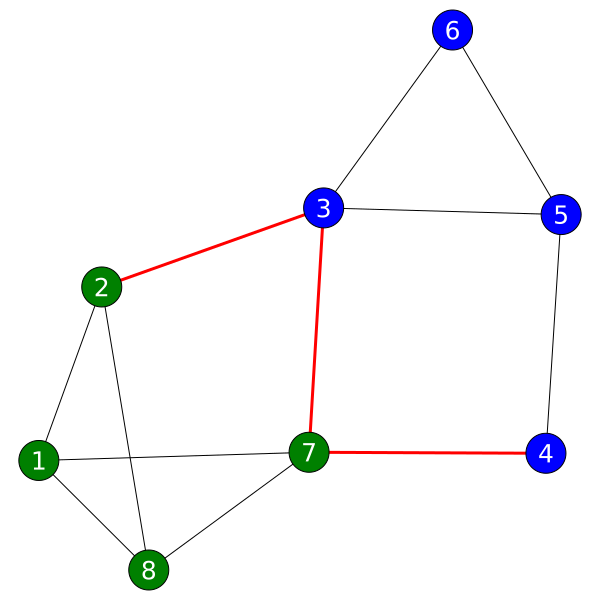

In [5]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/gpp_utils.jl")

# Create graph
graph = Graphs.Graph(8)

# Edges
edges = [(1,2), (1,7), (1,8), (2,3), (2,8), (3,5), (3,6), (3,7), (4,5), (4,7), (5,6), (7,8)]

# Add edges
for (u, v) in edges
    Graphs.add_edge!(graph, u, v)
end

# Total of vertices
n = Graphs.nv(graph)

# Total of edges
m = Graphs.ne(graph)

# Number of partitions
k = 2

# Auxiliary variables to simplify notation
V = 1:Graphs.nv(graph) # Range of vertices
E = 1:Graphs.ne(graph) # Range of edges
P = 1:k                # Range of partitions

# Define lower and upper size limits for each partition
L = floor(Int, n / k)
U = ceil(Int, n / k)

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, y[e in E], Bin)
@variable(model, x[v in V, p in P], Bin)

# Objective: minimize number of cut edges
@objective(model, Min, sum(y[e] for e in E))
    
# Each vertex must be assigned to exactly one partition
@constraint(model, [v in V], sum(x[v, p] for p in P) == 1)

# Partition balance constraint
@constraint(model, [p in P], sum(x[v, p] for v in V) >= L)
@constraint(model, [p in P], sum(x[v, p] for v in V) <= U)

# Define y[e] = 1 if edge connects different partitions
for (e_id, e) in enumerate(Graphs.edges(graph))
    u, v = e.src, e.dst
    for p in P
        @constraint(model, y[e_id] >= x[u, p] - x[v, p])
        @constraint(model, y[e_id] >= x[v, p] - x[u, p])
    end
end

# Run the solver
JuMP.optimize!(model)

# Print solution
println("Edge cuts total: ", JuMP.objective_value(model))
edge_cuts = falses(m)
for (e_id, e) in enumerate(Graphs.edges(graph))
    if JuMP.value(y[e_id]) > 0.5
        println("Edge cut: {$(e.src),$(e.dst)}")
        edge_cuts[e_id] = true
    end
end

# Extract partition from solution
partition = Vector{Vector{Int}}()
for p in P
    cluster = [v for v in V if JuMP.value(x[v,p]) > 0.5]
    push!(partition, cluster)
end
println("Partition: ", partition)

# Plot solution
plot_solution(graph, partition, edge_cuts, k)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.4.4 - Solving GPP using Metis</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Edge cut: {2,3}
Edge cut: {3,7}
Edge cut: {4,7}
Partition:
Cluster 1: [3, 4, 5, 6]
Cluster 2: [1, 2, 7, 8]


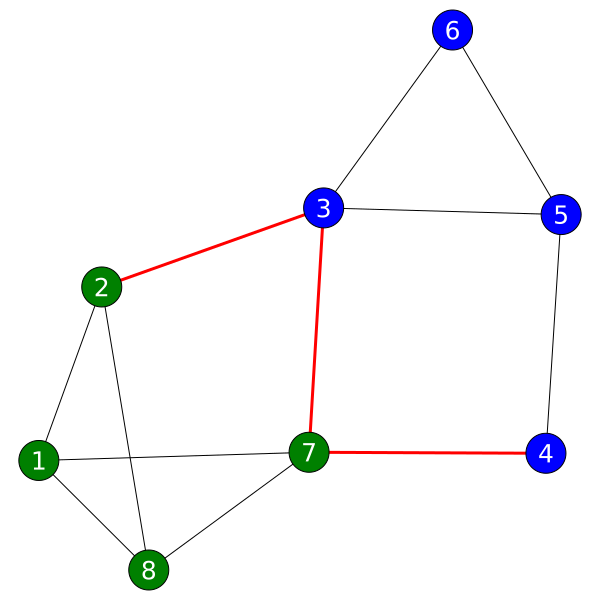

In [7]:
using Random # For random number generation
using Graphs # Graphs package
using Metis  # Metis package for graph partitioning

# Load utility function for plotting
include("utils/metis_utils.jl")

# Set seed for reproducibility
Random.seed!(0)

# Create graph
graph = Graphs.Graph(8)

# Edges
edges = [(1,2), (1,7), (1,8), (2,3), (2,8), (3,5), (3,6), (3,7), (4,5), (4,7), (5,6), (7,8)]

# Add edges
for (src, dst) in edges
    Graphs.add_edge!(graph, src, dst)
end

# Number of partitions
k = 2

# Partition the graph using Metis
partition = Metis.partition(graph, k)

# Print edge cuts
edge_cuts = falses(Graphs.ne(graph))
for (e_id, e) in enumerate(Graphs.edges(graph))
    src, dst = Graphs.src(e), Graphs.dst(e)
    if partition[src] != partition[dst]
        println("Edge cut: {$src,$dst}")
        edge_cuts[e_id] = true
    end
end

# Print the partition
println("Partition:")
for i in 1:k
    println("Cluster $i: ", findall(partition .== i))
end

# Plot the solution
plot_solution(graph, partition, edge_cuts, k)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.4.5 - Weighted Graph Partitioning Problem</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Edge cuts total: 12.0
Edge cut: {1,2}
Edge cut: {4,5}
Edge cut: {3,7}
Edge cut: {2,8}
Partition: [[2, 3, 5, 6], [1, 4, 7, 8]]


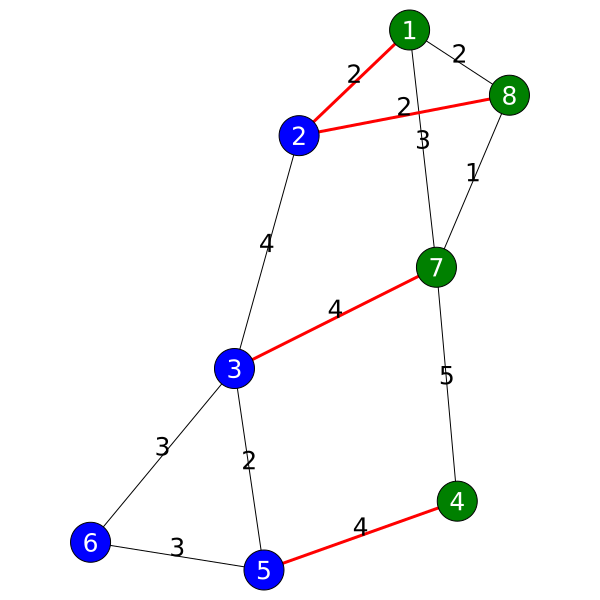

In [9]:
using JuMP                 # Modeling language
using HiGHS                # Solver
using Graphs               # Graphs package
using SimpleWeightedGraphs # For weighted graphs

# Load utility function for plotting
include("utils/wgpp_utils.jl")

# Create a weighted graph
graph = SimpleWeightedGraph(8)

# Add edges with weights
edges = [(1,2,2), (1,7,3), (1,8,2), (2,3,4), (2,8,2), (3,5,2), (3,6,3), (3,7,4), (4,5,4), (4,7,5), (5,6,3), (7,8,1)]
for (src, dst, w) in edges
    Graphs.add_edge!(graph, src, dst, w)
end

# Total of vertices
n = Graphs.nv(graph)

# Total of edges
m = Graphs.ne(graph)

# Number of partitions
k = 2

# Auxiliary variables to simplify notation
V = 1:Graphs.nv(graph) # Range of vertices
E = 1:Graphs.ne(graph) # Range of edges
P = 1:k                # Range of partitions

# Define lower and upper size limits for each partition
L = floor(Int, n / k)
U = ceil(Int, n / k)

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, y[e in E], Bin)
@variable(model, x[v in V, p in P], Bin)

# Objective: minimize the weight of cut edges
@objective(model, Min, sum(graph.weights[e.src, e.dst] * y[e_id] for (e_id, e) in enumerate(Graphs.edges(graph))))
    
# Each vertex must be assigned to exactly one partition
@constraint(model, [v in V], sum(x[v, p] for p in P) == 1)

# Partition balance constraint
@constraint(model, [p in P], sum(x[v, p] for v in V) >= L)
@constraint(model, [p in P], sum(x[v, p] for v in V) <= U)

# Define y[e] = 1 if edge connects different partitions
for (e_id, e) in enumerate(Graphs.edges(graph))
    u, v = e.src, e.dst
    for p in P
        @constraint(model, y[e_id] >= x[u, p] - x[v, p])
        @constraint(model, y[e_id] >= x[v, p] - x[u, p])
    end
end

# Run the solver
JuMP.optimize!(model)

# Print solution
println("Edge cuts total: ", JuMP.objective_value(model))
edge_cuts = falses(m)
for (e_id, e) in enumerate(Graphs.edges(graph))
    if JuMP.value(y[e_id]) > 0.5
        println("Edge cut: {$(e.src),$(e.dst)}")
        edge_cuts[e_id] = true
    end
end

# Extract partition from solution
partition = Vector{Vector{Int}}()
for p in P
    cluster = [v for v in V if JuMP.value(x[v,p]) > 0.5]
    push!(partition, cluster)
end
println("Partition: ", partition)

# Plot solution
plot_solution(graph, partition, edge_cuts, k)

<table>
  <tr>
    <td>Chapter</td>
    <td>5 - Graph Problems</td>
  </tr>
  <tr>
    <td>Section</td>
    <td>5.5.4 - Solving CPP with Julia</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

Modularity: 0.5416666666666666
Partition:
Cluster 1: 1 3 5 
Cluster 2: 2 12 15 
Cluster 3: 4 7 9 
Cluster 4: 6 17 19 
Cluster 5: 8 11 13 
Cluster 6: 10 18 21 
Cluster 7: 14 22 23 
Cluster 8: 16 20 24 


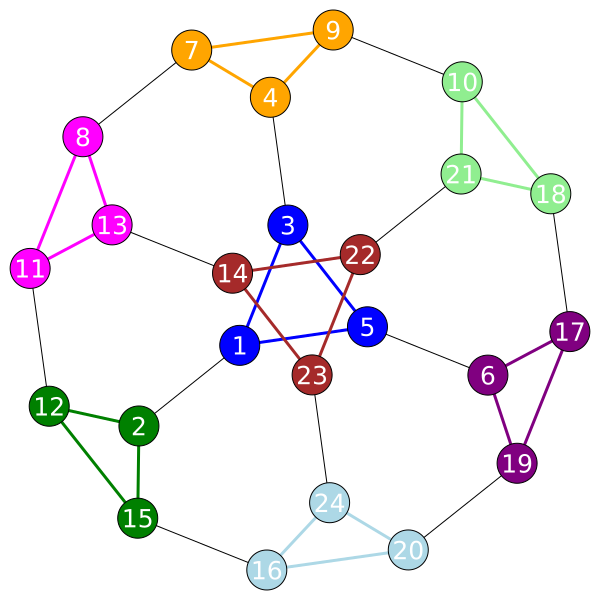

In [10]:
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Load utility function for plotting
include("utils/cpp_utils.jl")

# Create graph
graph = Graphs.smallgraph("truncatedcube")

# Get number of vertices and edges
n = Graphs.nv(graph)
m = Graphs.ne(graph)

# Auxiliary variables to simplify notation
V = 1:n

# Modularity matrix Q
Q = zeros(n,n)
for u in V
    for v in V
        du = Graphs.degree(graph, u)
        dv = Graphs.degree(graph, v)
        a_ij = Graphs.has_edge(graph, u, v) ? 1 : 0
        Q[u,v] = a_ij/(2*m) - (du * dv) / (4*m^2)
    end
end

# Create the model
model = JuMP.Model(HiGHS.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, x[u in V, v in V], Bin)

# Objective: maximize the weight of the selected edges
@objective(model, Max, sum(Q[u,v] * x[u,v] for u in V for v in V))

# Transitive Constraints: ensure that the selected edges form a valid partition
for u in V
    for v in V
        for w in V
            @constraint(model,  x[u,v] + x[v,w] - x[u,w] <= 1)
            @constraint(model,  x[u,v] - x[v,w] + x[u,w] <= 1)
            @constraint(model, -x[u,v] + x[v,w] + x[u,w] <= 1)
        end
    end
end

# Run the solver
JuMP.optimize!(model)

# Get the objective (modularity)
modularity = JuMP.objective_value(model)
println("Modularity: ", modularity)

# Extract the optimal partition
println("Partition:")
partition = zeros(Int64, n)
partition_id = 1
for u in V
    # If vertex u is not yet assigned to a partition
    if partition[u] == 0
        print("Cluster $partition_id: ")
        for v in V
            # If vertex v is in the same partition as u
            if JuMP.value(x[u,v]) > 0.5
                # Assign both u and v to the same partition
                partition[v] = partition_id
                print("$v ")
            end
        end
        print("\n")
        partition_id += 1
    end
end

# Plot solution
plot_solution(graph, partition)